In [1]:
# # Graphics and plotting.
# print('Installing mediapy:')
!command -v ffmpeg >/dev/null || (apt update && apt install -y ffmpeg)
# !pip install --force-reinstall mediapy 


In [2]:
# !pip install matplotlib==3.5.2

In [3]:
import matplotlib.pyplot as plt

import os
os.environ["MUJOCO_GL"] = "egl"

import mujoco
import numpy as np
import numpy.typing as npt

import mediapy as media


def render(model, data=None, height=300, camera=-1):
    if data is None:
      data = mujoco.MjData(model)
    with mujoco.Renderer(model, 480, 640) as renderer:
      mujoco.mj_forward(model, data)
      renderer.update_scene(data, camera)
      media.show_image(renderer.render(), height=height)

xml model of the gripper is from: https://github.com/personalrobotics/geodude_assets/tree/main

In [4]:
xml_path = "../src/robotiq_2f140/2f140.xml"

model = mujoco.MjModel.from_xml_path(xml_path) # '/workspace/gripper.urdf'

In [5]:
model

""

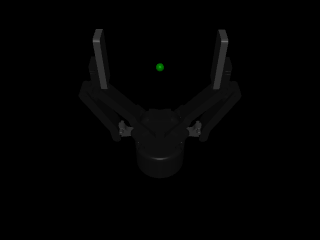

In [6]:
%matplotlib inline

data = mujoco.MjData(model)

# Make renderer, render and show the pixels
with mujoco.Renderer(model) as renderer:
    mujoco.mj_forward(model, data)
    renderer.update_scene(data)

    media.show_image(renderer.render())

In [7]:
xml_path = "../src/robotiq_2f140/2f140.xml"

model = mujoco.MjModel.from_xml_path(xml_path) # '/workspace/gripper.urdf'
data = mujoco.MjData(model)

n_frames = 60
height = 300
width = 300
frames = []

# Simulate and display video.
with mujoco.Renderer(model, height, width) as renderer:
  mujoco.mj_resetData(model, data)
  for i in range(n_frames):
    while data.time < i/30.0:
      mujoco.mj_step(model, data)
    renderer.update_scene(data)
    frame = renderer.render()
    frames.append(frame)

media.show_video(frames, fps=30)

In [8]:
# ur3e_model_path = "/workspace/src/mujoco_model/ur3e.xml"
ur3e_model_path = "../src/ur3e/scene.xml"

arm_model = mujoco.MjModel.from_xml_path(ur3e_model_path)
arm_data = mujoco.MjData(arm_model)


""

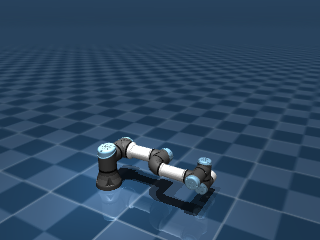

In [9]:
# Make renderer, render and show the pixels
with mujoco.Renderer(arm_model) as renderer:
    mujoco.mj_forward(arm_model, arm_data)
    renderer.update_scene(arm_data)

    media.show_image(renderer.render())

In [10]:

n_frames = 120
height = 300
width = 300
frames = []

# Simulate and display video.
with mujoco.Renderer(arm_model, height, width) as renderer:
  mujoco.mj_resetData(arm_model, arm_data)
  for i in range(n_frames):
    while arm_data.time < i/30.0:
      mujoco.mj_step(arm_model, arm_data)
    renderer.update_scene(arm_data)
    frame = renderer.render()
    frames.append(frame)

media.show_video(frames, fps=30)

This browser does not support the video tag.


From MjSpec

""

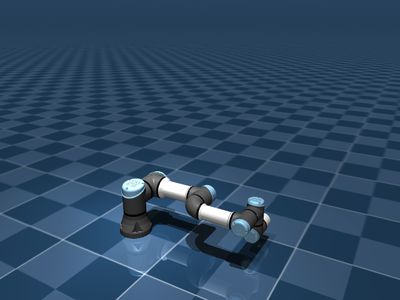

In [11]:
spec = mujoco.MjSpec.from_file(ur3e_model_path)

model = spec.compile()
render(model)

""

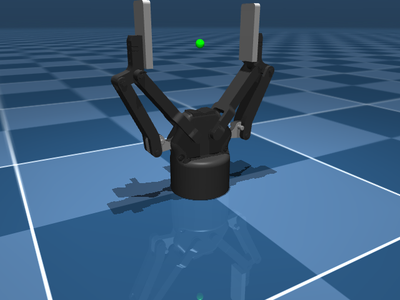

In [12]:
gripper_path = "../src/robotiq_2f140/scene.xml"
gripper_spec = mujoco.MjSpec.from_file(gripper_path)

gripper_model = gripper_spec.compile()
render(gripper_model)

In [13]:
[b.name for b in spec.bodies], [b.name for b in gripper_spec.bodies]

(['world',
  'base',
  'shoulder_link',
  'upper_arm_link',
  'forearm_link',
  'wrist_1_link',
  'wrist_2_link',
  'wrist_3_link'],
 ['world',
  'base_mount',
  'base',
  'right_driver',
  'right_coupler',
  'right_spring_link',
  'right_follower',
  'right_pad',
  'left_driver',
  'left_coupler',
  'left_spring_link',
  'left_follower',
  'left_pad',
  'object'])

impratio: parent has 1, child has 10, keeping parent value
viscosity: parent has 0, child has 0.1, keeping parent value
cone: parent has 0, child has 1, keeping parent value

/tmp/ipykernel_89082/959752785.py:29: UserWarning: Attach conflict when attaching '2f140 scene' to 'ur3e scene', policy is 'warning'
impratio: parent has 1, child has 10, keeping parent value
viscosity: parent has 0, child has 0.1, keeping parent value
cone: parent has 0, child has 1, keeping parent value
  model = spec.compile()


""

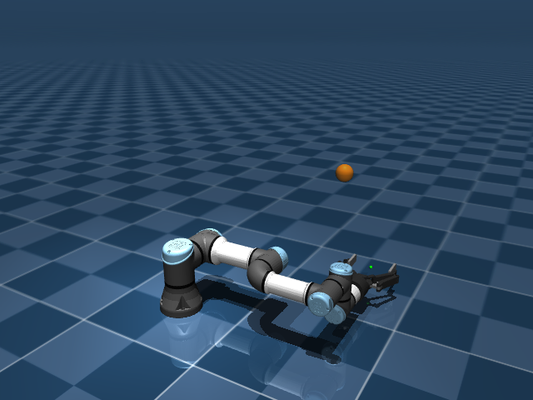

/tmp/ipykernel_89082/959752785.py:38: UserWarning: Attach conflict when attaching '2f140 scene' to 'ur3e scene', policy is 'warning'
impratio: parent has 1, child has 10, keeping parent value
viscosity: parent has 0, child has 0.1, keeping parent value
cone: parent has 0, child has 1, keeping parent value
  f.write(spec.to_xml())


In [14]:
spec = mujoco.MjSpec.from_file(ur3e_model_path)
spec.copy_during_attach = True

# Get the torso, arm, and leg bodies
flange = spec.body('wrist_3_link')

gripper_base_mount = gripper_spec.body('base_mount')

# Attach frames at the site positions
attachment_site = flange.sites[0]

# Add new legs
attachment_site.attach_body(gripper_base_mount, 'wrist_3_link', 'gripper')

## Add target sphere for reach skill
target_body = spec.worldbody.add_body(
    pos=[0.5, 0, 0.5],
    quat=[0, 1, 0, 0],
    )
target_body.add_geom(
    name='target_sphere', 
    type=mujoco.mjtGeom.mjGEOM_SPHERE, 
    size=[0.02], 
    rgba=[1, 0.5, 0, 0.5], 
    group=1
    )


model = spec.compile()

data = mujoco.MjData(model)


render(model, height=400)

# 4. Save the combined structural layout out to a clean XML file
with open("combined_robot_gripper.xml", "w") as f:  
    f.write(spec.to_xml())                          

""

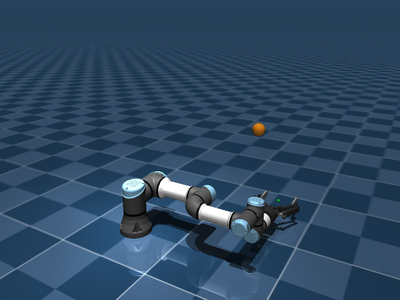

In [15]:
combined_robot_path = "../src/reach_skill/combined_robot_gripper.xml"
combined_robot_spec = mujoco.MjSpec.from_file(combined_robot_path)

combined_robot_model = combined_robot_spec.compile()
render(combined_robot_model)

In [16]:
site_id = mujoco.mj_name2id(model, mujoco.mjtObj.mjOBJ_SITE, "attachment_site")
data.site("attachment_site").xpos, data.site_xpos, data.site("attachment_site").id


(array([0., 0., 0.]),
 array([[0., 0., 0.],
        [0., 0., 0.]]),
 0)

""

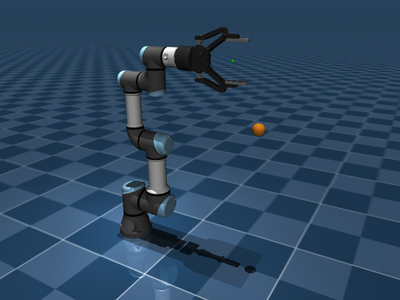

In [17]:
data = mujoco.MjData(model)
data.qpos[0:2] = [-1.57, -1.57]

data.qpos[2] = 0

data.qpos[3] = -1.57
data.qpos[4] = 0

data.qpos[5] = 1.57

data.qpos[6] = 0

gripper_value = 0.1 # Range [0.0, 0.8]
data.qpos[7] = -gripper_value
data.qpos[8] = -gripper_value
data.qpos[9] = gripper_value

data.qpos[10] = 0
data.qpos[11] = -gripper_value
data.qpos[12] = -gripper_value

data.qpos[13] = gripper_value

for i in range(6):
    data.ctrl[i] = data.qpos[i]

with mujoco.Renderer(model, 480, 640) as renderer:
    mujoco.mj_forward(model, data)
    renderer.update_scene(data)
    media.show_image(renderer.render(), height=height)

if True:
    mujoco.mj_saveLastXML("ur3e_with_gripper.xml", model)


In [20]:
delta_action_limit = np.array([
        0.02, # Joint0 : Base 191 deg/s     -> 1.91 deg/0.01s -> 0.03 rad/0.01s| use 0.02
        0.02, # Joint1 : Shoulder 191 deg/s -> 1.91 deg/0.01s -> 0.03 rad/0.01s| use 0.02
        0.02, # Joint2 : Elbow 191 deg/s    -> 1.91 deg/0.01s -> 0.03 rad/0.01s| use 0.02
        0.04, # Joint3 : Wrist_1 371 deg/s  -> 3.71 deg/0.01s -> 0.06 rad/0.01s| use 0.04
        0.04, # Joint4 : Wrist_2 371 deg/s  -> 3.71 deg/0.01s -> 0.06 rad/0.01s| use 0.04
        0.04, # Joint5 : Wrist_3 371 deg/s  -> 3.71 deg/0.01s -> 0.06 rad/0.01s| use 0.04
        # [   -1, 1]     # Gripper range [0, 255] -> completely close in 2s -> 127 / s -> 1.27/0.01s | use 1
        ])

delta_action_limit.shape

envs_delta_action_limit = np.ones((8, 6)) * delta_action_limit
envs_delta_action_limit, -1 * envs_delta_action_limit

np.clip(np.ones((8, 6)) * 100, -1 * envs_delta_action_limit, envs_delta_action_limit)

array([[0.02, 0.02, 0.02, 0.04, 0.04, 0.04],
       [0.02, 0.02, 0.02, 0.04, 0.04, 0.04],
       [0.02, 0.02, 0.02, 0.04, 0.04, 0.04],
       [0.02, 0.02, 0.02, 0.04, 0.04, 0.04],
       [0.02, 0.02, 0.02, 0.04, 0.04, 0.04],
       [0.02, 0.02, 0.02, 0.04, 0.04, 0.04],
       [0.02, 0.02, 0.02, 0.04, 0.04, 0.04],
       [0.02, 0.02, 0.02, 0.04, 0.04, 0.04]])

In [21]:
data.qpos, data.qvel, model.nu, len(data.qvel), data.ctrl, model.actuator_ctrlrange

(array([-1.57, -1.57,  0.  , -1.57,  0.  ,  1.57,  0.  , -0.1 , -0.1 ,
         0.1 ,  0.  , -0.1 , -0.1 ,  0.1 ]),
 array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.]),
 7,
 14,
 array([-1.57, -1.57,  0.  , -1.57,  0.  ,  1.57,  0.  ]),
 array([[ -6.2831,   6.2831],
        [ -6.2831,   6.2831],
        [ -6.2831,   6.2831],
        [ -6.2831,   6.2831],
        [ -6.2831,   6.2831],
        [ -6.2831,   6.2831],
        [  0.    , 255.    ]]))

In [47]:
data = mujoco.MjData(model)

# Episode parameters.
duration = 3       # (seconds)
framerate = 60     # (Hz)
data.qpos[0:2] = [-.5, -.5]  # Initial x-y position (m)
data.qvel[2] = 4   # Initial vertical velocity (m/s)
ctrl_phase = 2 * np.pi * np.random.rand(model.nu)  # Control phase
ctrl_freq = 1     # Control frequency


control_signal = []
states = []
# Simulate and render.
frames = []
with mujoco.Renderer(model, 480, 640) as renderer:
  while data.time < duration:
    # Sinusoidal control signal.
    data.ctrl = np.sin(ctrl_phase + 2 * np.pi * data.time * ctrl_freq)
    states.append(data.qpos[:6].copy())
    control_signal.append(data.ctrl.tolist())
    # data.ctrl = np.array([0, -1.57, 0, -1.57, .0, 1.57, 200])
    mujoco.mj_step(model, data)
    if len(frames) < data.time * framerate:
      # This draws the regular humanoid from `data`.
      renderer.update_scene(data)

      # Render and add the frame.
      pixels = renderer.render()
      frames.append(pixels)

# Render video at half real-time.
media.show_video(frames, fps=framerate/2)

This browser does not support the video tag.


<Axes: >

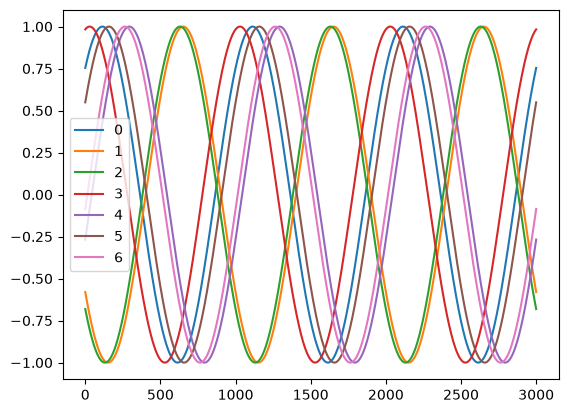

In [52]:
import pandas as pd


a = np.array(control_signal)
# pd.DataFrame(a.tolist()).diff().describe()
pd.DataFrame(a.tolist()).plot()

<Axes: >

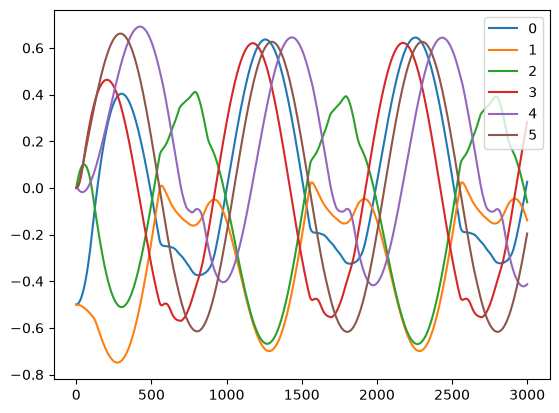

In [53]:
s = np.array(states)
# pd.DataFrame(a.tolist()).diff().describe()
pd.DataFrame(s.tolist()).plot()

In [ ]:
data = mujoco.MjData(model)
data2 = mujoco.MjData(model)

# Episode parameters.
duration = 3       # (seconds)
framerate = 60     # (Hz)
data.qpos[0:2] = [-.5, -.5]  # Initial x-y position (m)
data.qvel[2] = 4   # Initial vertical velocity (m/s)
ctrl_phase = 2 * np.pi * np.random.rand(model.nu)  # Control phase
ctrl_freq = 1     # Control frequency

# Simulate and render.
frames = []
with mujoco.Renderer(model, 480, 640) as renderer:
  while data.time < duration:
    # Sinusoidal control signal.
    data.ctrl = np.sin(ctrl_phase + 2 * np.pi * data.time * ctrl_freq)
    mujoco.mj_step(model, data)
    if len(frames) < data.time * framerate:
      # This draws the regular humanoid from `data`.
      renderer.update_scene(data)

      # Render and add the frame.
      pixels = renderer.render()
      frames.append(pixels)

# Render video at half real-time.
media.show_video(frames, fps=framerate/2)

This browser does not support the video tag.
